In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

df = pd.read_csv("../data/raw/telco_churn.csv")

In [4]:
df.shape

(7043, 33)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df["Churn"].value_counts(normalize=True)

KeyError: 'Churn'

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df["Churn Value"].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [ ]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, numerical_cols

(Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
        'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
        'Multiple Lines', 'Internet Service', 'Online Security',
        'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
        'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
        'Total Charges', 'Churn Label', 'Churn Reason'],
       dtype='object'),
 Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
        'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
       dtype='object'))

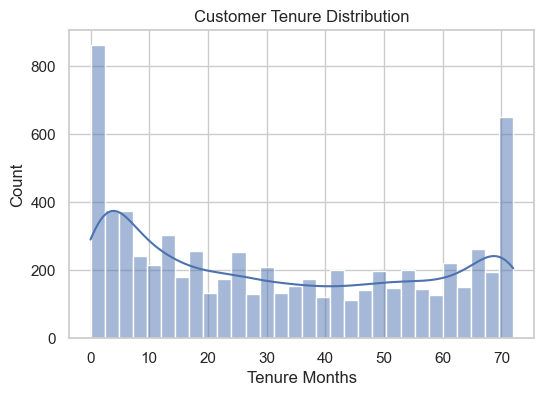

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Tenure Months"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

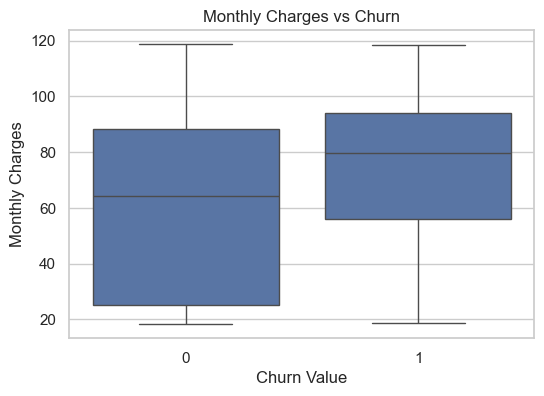

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn Value", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

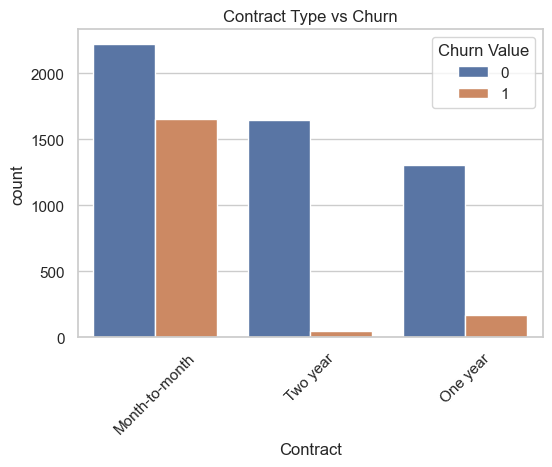

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn Value", data=df)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

In [ ]:
# segmentation phse

In [10]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].isnull().sum()

np.int64(11)

In [16]:
df = df.dropna(subset=["Total Charges"]).copy()

In [17]:
service_cols = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]

df["ServiceCount"] = (df[service_cols] == "Yes").sum(axis=1)

In [20]:
segmentation_features = ["Tenure Months", "Monthly Charges", "Total Charges", "ServiceCount"]

seg_df = df[segmentation_features].copy()
seg_df.head()

,Tenure Months,Monthly Charges,Total Charges,ServiceCount
0,2,53.85,108.15,3
1,2,70.70,151.65,1
2,8,99.65,820.50,5
3,28,104.80,3046.05,6
4,49,103.70,5036.30,6


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_df)

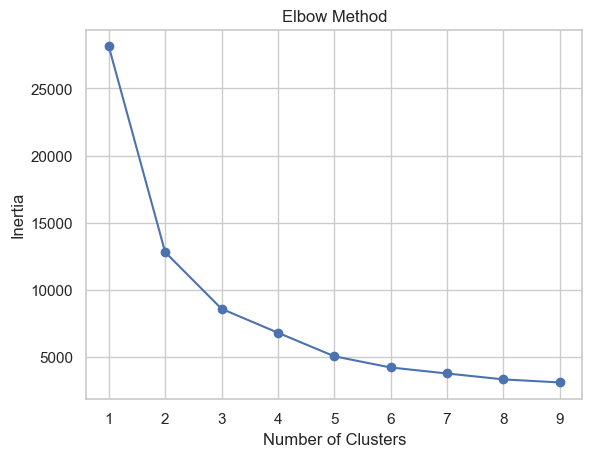

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(seg_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(seg_scaled)
    score = silhouette_score(seg_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.4670
K=3, Silhouette Score=0.4089
K=4, Silhouette Score=0.3688
K=5, Silhouette Score=0.3873
K=6, Silhouette Score=0.3723
K=7, Silhouette Score=0.3662


In [30]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Segment"] = kmeans.fit_predict(seg_scaled)

In [31]:
df.groupby("Segment")[segmentation_features].mean()

,Tenure Months,Monthly Charges,Total Charges,ServiceCount
Segment,,,,
0,58.837825,90.671277,5321.121182,5.653901
1,26.409781,28.360519,709.339165,1.364671
2,16.072299,77.257407,1225.715088,3.322593
